In [51]:
import numpy as np
import ROOT
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
import multiprocessing as mp

sort_dir = "./neutrinos/sorted"
rtd_dir = "./neutrinos/rtd"
src_dir = "./neutrinos/raw"

ROOT.EnableImplicitMT()

### Files Setup

In [52]:
%load_ext autoreload
%autoreload 2
from neutrinoAna import getFiles, UpdateSrc
rtd_files = getFiles(rtd_dir)
sort_files = getFiles(sort_dir)
src_files = getFiles(src_dir)
nBins = int(np.sqrt(len(rtd_files)))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
idf = pd.read_csv('neutrinoAna.csv')

### Hist Setup

median total resets: 1875.0
median tile resets: 1846.0
median e deposit: 117.93892842416193


array([<AxesSubplot:title={'center':'muonReco'}>], dtype=object)

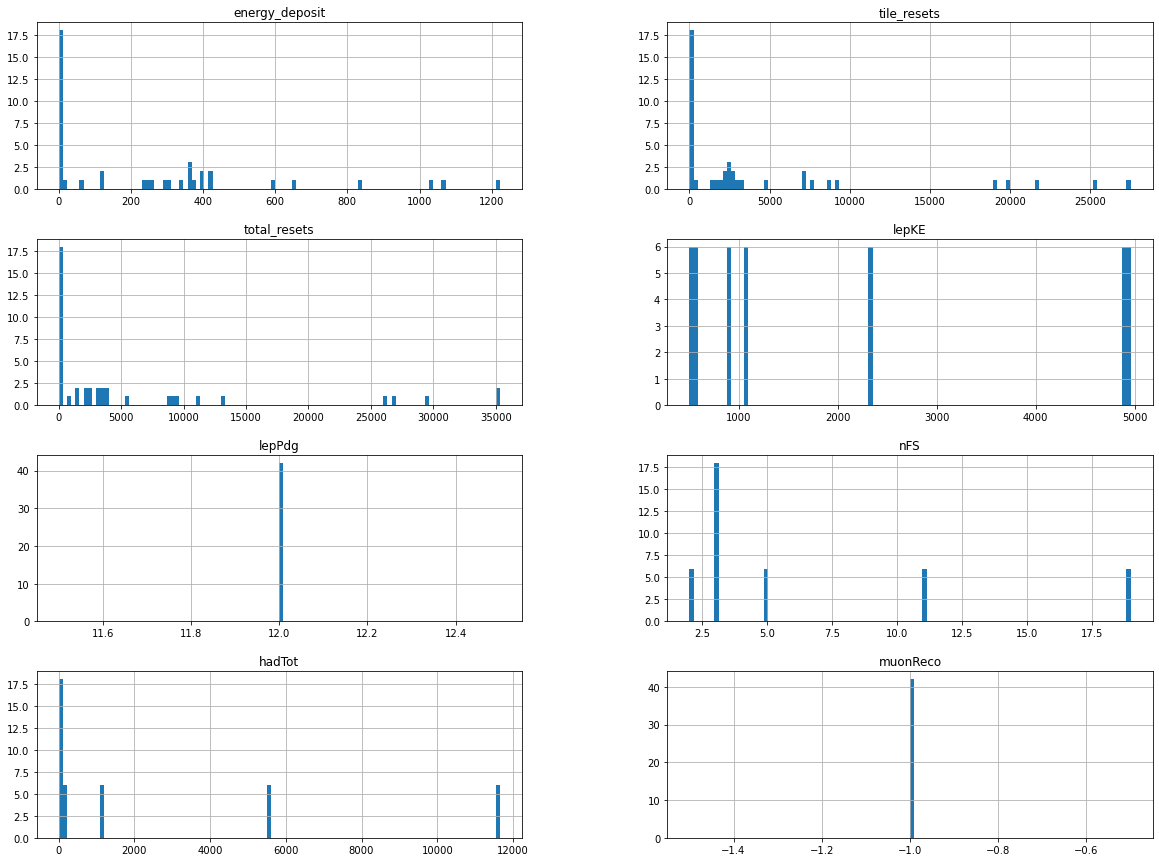

In [56]:
v = df['total_resets'].median()
print('median total resets:', v)
v = df['tile_resets'].median()
print('median tile resets:', v)
v = df['energy_deposit'].median()
print('median e deposit:', v)
# pdg numbers
# e–	11
# νe	12
# μ–	13
# νμ	14
# τ–	15
# ντ	16
# τ'–	17
# ντ'	18
# filters
df = idf[(idf['lepKE'] < 8000) & (idf['lepPdg'] == 12)]

#define subplot layout
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20,15))
df.hist('energy_deposit', bins=nBins, ax=axes[0][0])
df.hist('total_resets', bins=nBins, ax=axes[1][0])
df.hist('tile_resets', bins=nBins, ax=axes[0][1])
df.hist('lepKE', bins=nBins, ax=axes[1][1])
df.hist('lepPdg', bins=nBins, ax=axes[2][0])
df.hist('nFS', bins=nBins, ax=axes[2][1])
df.hist('hadTot', bins=nBins, ax=axes[3][0])
df.hist('muonReco', bins=nBins, ax=axes[3][1])

### High reset files

In [29]:
# max energy deposit is not the same as the max reset count
max_reset = df.loc[df['total_resets'].idxmax()]['sortFile']
max_energy_deposit = df.loc[df['energy_deposit'].idxmax()]['sortFile']
max_total_resets = df.loc[df['total_resets'].idxmax()]['sortFile']
print(f"max reset file: {max_reset}")
print(f"max e deposit file {max_energy_deposit}")
print(f"max total reset file {max_total_resets}")

max reset file: C:\Users\keefe\OneDrive\Documents\qpix-digital\simulation-rtd\hits\neutrinos\sorted\FHC_793_x-120_y-320_z-10_seed-420_zaxis-1_sorted.root
max e deposit file C:\Users\keefe\OneDrive\Documents\qpix-digital\simulation-rtd\hits\neutrinos\sorted\FHC_760_x-120_y-320_z-80_seed-420_zaxis-0_sorted.root
max total reset file C:\Users\keefe\OneDrive\Documents\qpix-digital\simulation-rtd\hits\neutrinos\sorted\FHC_793_x-120_y-320_z-10_seed-420_zaxis-1_sorted.root


#### get the ttree of the max rdf file, and show what the hits look like

In [30]:
def findSorted(sorted_file):
    import os
    if os.name != 'nt':
        sorted_file = sorted_file.replace("\\", "/")
        sorted_file = sorted_file.replace("C:", "/mnt/c")
    return sorted_file

In [31]:
def viewEvent(sorted_file, cvname="c", canvas=None):
    """
    take an input sorted file, and draw the neutrino event
    """
    sorted_file = findSorted(sorted_file)
    tf = ROOT.TFile(sorted_file, "READ")
    tt = tf.event_tree
    if canvas is None:
        c = ROOT.TCanvas(cvname, cvname, 500, 500)
    if hasattr(tt, 'hit_start_x'):
        tt.Draw("hit_start_x:hit_start_y:hit_start_z")
    else:
        print('WARNING tree does not have hit branches')
    if canvas is None:
        c.Draw()
        return c
    else:
        return canvas

In [32]:
def viewProcesses(sorted_file, cvname="c", canvas=None):
    sorted_file = findSorted(sorted_file)
    tf = ROOT.TFile(sorted_file, "READ")
    tt = tf.event_tree
    if canvas is None:
        c = ROOT.TCanvas(cvname, cvname, 500, 500)
    if hasattr(tt, 'hit_process_key'):
        tt.Draw("hit_process_key")
    else:
        print('WARNING tree does not have hit process branch')
    if canvas is None:
        c.Draw()
        return c
    else:
        return canvas

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canv


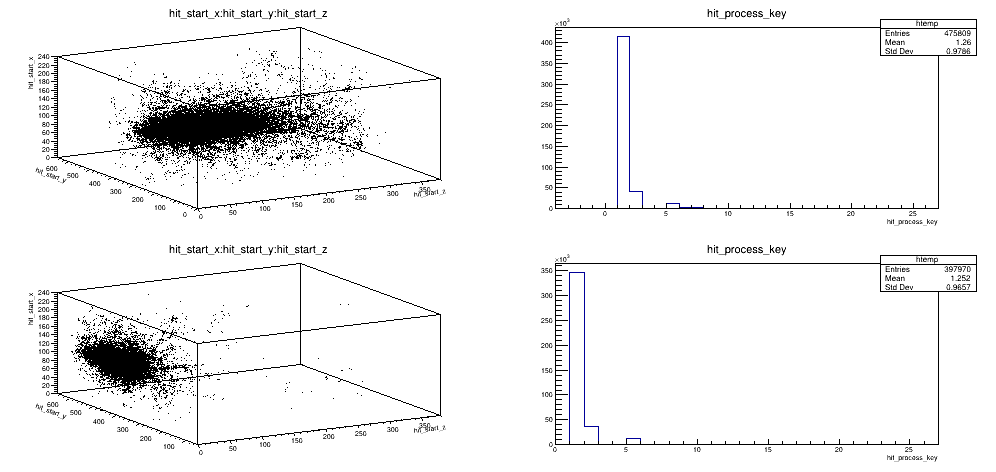

In [33]:
## verify that the rotation angle works
canv = ROOT.TCanvas("canv", "canv", 1000, 500)
canv.Divide(2,2)
canv.cd(1)
f = viewEvent(max_reset, "f", canv)
canv.cd(2)
e = viewProcesses(max_reset, "e", canv)
swap_reset = max_reset.replace("zaxis-1", "zaxis-0")
canv.cd(3)
g = viewEvent(swap_reset, "f", canv)
canv.cd(4)
h = viewProcesses(swap_reset, "e", canv)
canv.Draw()

### Visual full csv

#### boxplot

[]

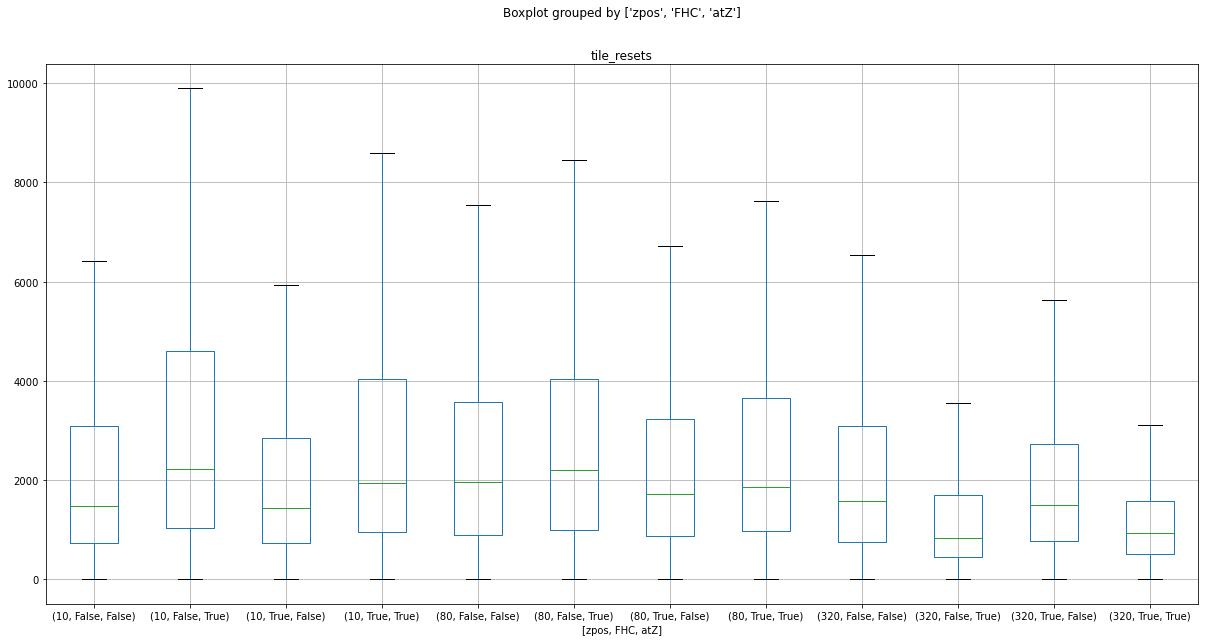

In [34]:
cdf = df
a = cdf.boxplot('tile_resets', by=['zpos','FHC','atZ'], sym="", figsize=(20,10))
a.plot()

#### scatter and means

<bound method NDFrame.head of zpos  FHC    atZ  
10    False  False    3883.084677
             True     5335.759073
      True   False    3847.612653
             True     5035.427303
80    False  False    4808.910282
             True     5180.637097
      True   False    4459.907880
             True     4810.336293
320   False  False    4291.563508
             True     1551.395161
      True   False    3972.743618
             True     1478.489456
Name: tile_resets, dtype: float64>


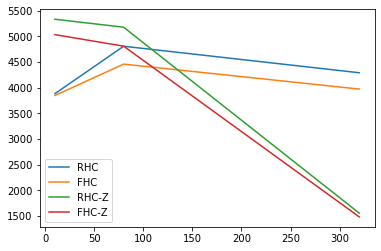

In [35]:
cdf = df.groupby(['zpos', 'FHC', 'atZ'])
means = cdf.mean()
stds = cdf.std()
ind = means.index
ndf = pd.DataFrame()
zs = sorted(df['zpos'].unique())

print(means['tile_resets'].head)

plot_data = [ [], [], [], [] ]
plot_err = [ [], [], [], [] ]
names = ["RHC", "FHC", "RHC-Z", "FHC-Z"]

for i in ind:
    id = int(i[1])+2*int(i[2])
    plot_data[id].append(means.loc[i]['tile_resets'])
    plot_err[id].append(stds.loc[i]['tile_resets'])

for i in range(4):
    plt.plot(zs, plot_data[i], label=f"{names[i]}")
plt.legend()  
# df.plot('zpos', 'total_resets', kind='scatter')